In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import math


MAX_OCCUPANCY = 0.36  # Maximum occupancy rate (36%) - To avoid overcrowding

In [2]:
def random_color():
    return (
        random.randint(0, 255),
        random.randint(0, 255),
        random.randint(0, 255),
    )


def draw_circles(canvas, count, max_area):
    h, w, _ = canvas.shape
    max_radius = int(math.sqrt(max_area / math.pi))

    for _ in range(count):
        radius = random.randint(10, min(max_radius, min(w, h)//2))
        center = (
            random.randint(radius, w - radius),
            random.randint(radius, h - radius)
        )
        cv2.circle(canvas, center, radius, random_color(), -1)


def draw_squares(canvas, count, max_area):
    h, w, _ = canvas.shape
    max_side = int(math.sqrt(max_area))

    for _ in range(count):
        side = random.randint(20, min(max_side, min(w, h)))
        x = random.randint(0, w - side)
        y = random.randint(0, h - side)
        cv2.rectangle(canvas, (x, y), (x + side, y + side), random_color(), -1)


def draw_rectangles(canvas, count, max_area):
    h, w, _ = canvas.shape

    for _ in range(count):
        # keep trying until valid rectangle fits
        for _ in range(50):  # max attempts
            width = random.randint(30, min(w, int(math.sqrt(max_area))))
            max_height = int(max_area / width)

            if max_height < 30:
                continue

            height = random.randint(30, min(max_height, h))

            if width <= w and height <= h:
                x = random.randint(0, w - width)
                y = random.randint(0, h - height)
                cv2.rectangle(canvas, (x, y), (x + width, y + height), random_color(), -1)
                break


def draw_triangles(canvas, count, max_area):
    h, w, _ = canvas.shape
    max_side = int(math.sqrt(max_area))

    for _ in range(count):
        side = random.randint(30, min(max_side, min(w, h)))
        x = random.randint(0, w - side)
        y = random.randint(0, h - side)

        pts = np.array([
            [x, y],
            [x + side, y],
            [x + side // 2, y + side]
        ])
        cv2.fillPoly(canvas, [pts], random_color())


def draw_random_polygons(canvas, count, max_area):
    h, w, _ = canvas.shape
    max_radius = int(math.sqrt(max_area))

    for _ in range(count):
        sides = random.randint(5, 8)
        radius = random.randint(20, min(max_radius, min(w, h)//2))

        center_x = random.randint(radius, w - radius)
        center_y = random.randint(radius, h - radius)

        pts = []
        for i in range(sides):
            angle = 2 * math.pi * i / sides
            x = int(center_x + radius * math.cos(angle))
            y = int(center_y + radius * math.sin(angle))
            pts.append([x, y])

        pts = np.array(pts)
        cv2.fillPoly(canvas, [pts], random_color())


In [3]:
def main():
    width = 1000
    height = 700

    canvas = np.ones((height, width, 3), dtype=np.uint8) * 255

    total_area = width * height
    max_area = total_area * MAX_OCCUPANCY

    print("Enter values: Circles Squares Rectangles Triangles Polygons")
    print("Example: 5 6 12 8 2")

    values = list(map(int, input("Enter values: ").split()))

    if len(values) != 5:
        print("Enter exactly 5 numbers.")
        return

    circles, squares, rectangles, triangles, polygons = values

    draw_circles(canvas, circles, max_area)
    draw_squares(canvas, squares, max_area)
    draw_rectangles(canvas, rectangles, max_area)
    draw_triangles(canvas, triangles, max_area)
    draw_random_polygons(canvas, polygons, max_area)

    canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(canvas_rgb)
    plt.title("Abstract Art ")
    plt.axis("off")
    plt.show()

    # in case if you want to save the image, uncomment the line below 
    # cv2.imwrite("abstract_art.png", canvas)

Enter values: Circles Squares Rectangles Triangles Polygons
Example: 5 6 12 8 2


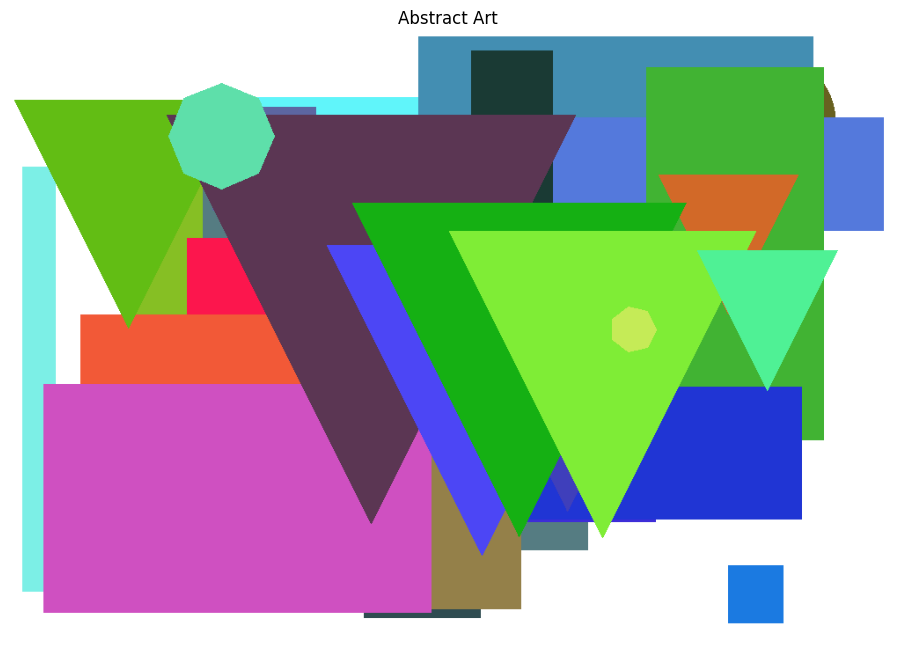

In [5]:
if __name__ == "__main__":
    main()